In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2026-04-03
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

XGBoost Regression — OJ Dataset (ISLR Ch. 8)
============================================

Description:
    Companion notebook to boosting_grad_boost_regression_ISLR_OJ.ipynb.
    Uses the native xgboost.XGBRegressor instead of sklearn's
    GradientBoostingRegressor, providing an exact 1:1 match to the
    original R caret::train(method='xgbTree') hyperparameters.

    Predicts SalePriceMM (sale price of Minute Maid OJ) from
    PriceDiff, PctDiscMM, and SalePriceCH.

    R hyperparameter mapping (exact, not approximate):
      nrounds=500         → n_estimators=500
      max_depth=3         → max_depth=3
      eta=0.2             → learning_rate=0.2
      gamma=2.1           → gamma=2.1          ← exact match
      colsample_bytree=1  → colsample_bytree=1  ← exact match
      min_child_weight=1  → min_child_weight=1  ← exact match
      subsample=1         → subsample=1         ← exact match

    Installation (run once in myenv terminal):
        pip install xgboost

    Verified compatible:
        xgboost >= 3.2.0  (Python >= 3.10, macOS Apple Silicon ARM64)
        https://pypi.org/project/xgboost/

    Covers:
      - pip install note and version check
      - Data loading and preparation (same as grad_boost notebook)
      - XGBRegressor fit with sklearn cross-validation API
      - Native XGBoost eval watchlist (train + test RMSE per round)
      - Feature importances: weight, gain, cover
      - GridSearchCV hyperparameter tuning
      - Predictions, scatter plot, RMSE and R-squared
      - Side-by-side comparison: XGBoost vs GradientBoostingRegressor

    R equivalent: boosting_train_caret_regression_ISLR_OJ.Rmd
    R libraries:  caret (train/trainControl, xgbTree), ISLR, ggplot2
    Python libs:  xgboost, ISLP, numpy, pandas, matplotlib, seaborn, sklearn

Dataset:
    OJ {ISLR/ISLP} — Orange Juice purchase data
    1070 observations, 18 variables
    Response variable: SalePriceMM (Sale Price of Minute Maid OJ, USD)
    Predictors: PriceDiff, PctDiscMM, SalePriceCH

Revision History:
    2026-04-03  Original Python development
                - Companion to boosting_grad_boost_regression_ISLR_OJ.ipynb
                - Uses xgboost.XGBRegressor for exact R xgbTree equivalence
                - Added native XGBoost eval watchlist (not available in sklearn GB)
                - Added three importance types: weight, gain, cover
"""

"\nCreated on 2026-04-03\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nXGBoost Regression — OJ Dataset (ISLR Ch. 8)\n============================================\n\nDescription:\n    Companion notebook to boosting_grad_boost_regression_ISLR_OJ.ipynb.\n    Uses the native xgboost.XGBRegressor instead of sklearn's\n    GradientBoostingRegressor, providing an exact 1:1 match to the\n    original R caret::train(method='xgbTree') hyperparameters.\n\n    Predicts SalePriceMM (sale price of Minute Maid OJ) from\n    PriceDiff, PctDiscMM, and SalePriceCH.\n\n    R hyperparameter mapping (exact, not approximate):\n      nrounds=500         → n_estimators=500\n      max_depth=3         → max_depth=3\n      eta=0.2             → learning_rate=0.2\n      gamma=2.1         

# XGBoost Regression — OJ Dataset (ISLR Ch. 8)

## Overview

This notebook is a **companion to** `boosting_grad_boost_regression_ISLR_OJ.ipynb`.
It uses the **native `xgboost.XGBRegressor`** instead of sklearn's
`GradientBoostingRegressor`, providing an **exact 1:1 mapping** to the original
R `caret::train(method='xgbTree')` hyperparameters — no approximations.

**Why a separate notebook?**
- `xgboost` requires a separate `pip install` (not bundled with sklearn)
- The native XGBoost API exposes features not available in sklearn's wrapper:
  the **eval watchlist** (live train/test RMSE per round) and three importance
  types (`weight`, `gain`, `cover`)
- Hyperparameters like `gamma`, `colsample_bytree`, `min_child_weight` map
  **exactly** — no scale approximation needed

**Same dataset and predictors as notebook #6:**
- Response: `SalePriceMM`
- Predictors: `PriceDiff`, `PctDiscMM`, `SalePriceCH`

**R equivalent:** `boosting_train_caret_regression_ISLR_OJ.Rmd`
(`method='xgbTree'`)

## Installation

Run once in your `myenv` terminal before opening this notebook:

```bash
pip install xgboost
```

**Version info:**
- Current stable: `xgboost 3.2.0` (Feb 2026)
- Requires: Python ≥ 3.10 (your environment: Python 3.14.3 ✓)
- macOS Apple Silicon: native ARM64 wheel — installs automatically on M5 ✓
- Docs: https://xgboost.readthedocs.io
- PyPI: https://pypi.org/project/xgboost/

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost — native API, exact match to R caret::train(method='xgbTree')
# Install: pip install xgboost
import xgboost as xgb
from xgboost import XGBRegressor

# sklearn — cross-validation and metrics only
from sklearn.model_selection import (train_test_split, RepeatedKFold,
                                      GridSearchCV, cross_val_score)
from sklearn.metrics import root_mean_squared_error, r2_score

# sklearn GradientBoostingRegressor — for final comparison only
from sklearn.ensemble import GradientBoostingRegressor

# ISLP — official dataset companion to ISL with Python
from ISLP import load_data

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print(f'XGBoost version : {xgb.__version__}')
print('Imports complete.')

XGBoost version : 3.2.0
Imports complete.


### R xgbTree → XGBRegressor Hyperparameter Mapping (Exact)

Unlike the sklearn `GradientBoostingRegressor` companion notebook, all
hyperparameters map **exactly** — same names, same scales:

| R (xgbTree / caret) | Value | Python (XGBRegressor) | Match |
|---------------------|-------|-----------------------|-------|
| `nrounds` | 500 | `n_estimators` | ✓ exact |
| `max_depth` | 3 | `max_depth` | ✓ exact |
| `eta` | 0.2 | `learning_rate` | ✓ exact |
| `gamma` | 2.1 | `gamma` | ✓ **exact** |
| `colsample_bytree` | 1 | `colsample_bytree` | ✓ **exact** |
| `min_child_weight` | 1 | `min_child_weight` | ✓ **exact** |
| `subsample` | 1 | `subsample` | ✓ exact |

## Helper Functions

In [3]:
def plot_predictions(y_actual, y_pred, title='', subtitle='Dataset: OJ {ISLR/ISLP}',
                     xlabel='Sale Price MM (USD)', ylabel='Predictions',
                     color=ROYALBLUE):
    """
    Scatter plot of actual vs. predicted values with regression line.
    Mirrors R: ggplot + geom_point + geom_smooth(method='lm', col='red')
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(y_actual, y_pred, alpha=0.4, s=20, color=color)
    m_fit  = np.polyfit(y_actual, y_pred, 1)
    x_line = np.linspace(min(y_actual), max(y_actual), 100)
    ax.plot(x_line, np.polyval(m_fit, x_line), color='red', linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\n{subtitle}' if subtitle else title)
    plt.tight_layout()
    plt.show()


def plot_xgb_importance(model, importance_type='gain',
                         title=None, color=ROYALBLUE):
    """
    Horizontal bar chart of XGBoost feature importances.
    Mirrors R: plot(varImp(boo)) and varImp(boo)$importance

    XGBoost exposes three importance types (unlike sklearn GB):
      'weight' : number of times a feature is used to split across all trees
      'gain'   : average gain of splits using the feature  ← most informative
      'cover'  : average coverage (number of samples) of splits using the feature

    Parameters
    ----------
    model          : fitted XGBRegressor
    importance_type: str — 'weight', 'gain', or 'cover'
    title          : str
    color          : str
    """
    scores = model.get_booster().get_score(importance_type=importance_type)
    imp    = pd.Series(scores).sort_values(ascending=True)

    if title is None:
        title = f'Feature Importances (type={importance_type})'

    fig, ax = plt.subplots(figsize=(7, 3))
    imp.plot(kind='barh', ax=ax, color=color, edgecolor='none', alpha=0.85)
    ax.set_xlabel(f'Importance ({importance_type})')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    print(f'Feature importances by {importance_type} (sorted descending):')
    print(imp.sort_values(ascending=False).round(4).to_string())


print('Helper functions defined.')

Helper functions defined.


---

## Dataset and Preparation

Identical to notebook #6. See that notebook for full EDA.

In [4]:
# Load OJ — mirrors R: data(OJ, package='ISLR')
OJ = load_data('OJ')

# Predictors — mirrors R: SalePriceMM ~ PriceDiff + PctDiscMM + SalePriceCH
FEATURES = ['PriceDiff', 'PctDiscMM', 'SalePriceCH']
RESPONSE = 'SalePriceMM'

OJ_enc = OJ[FEATURES + [RESPONSE]].copy()

# Train/test split — mirrors R: set.seed(1234), prob=c(0.7, 0.3)
train_df, test_df = train_test_split(OJ_enc, test_size=0.3, random_state=1234)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

X_train = train_df[FEATURES]
y_train = train_df[RESPONSE]
X_test  = test_df[FEATURES]
y_test  = test_df[RESPONSE]

print(f'Train shape : {X_train.shape}')
print(f'Test shape  : {X_test.shape}')

Train shape : (749, 3)
Test shape  : (321, 3)


---

# XGBoost Model — Fixed Hyperparameters (Exact R Mirror)

Mirrors R:
```r
boo <- train(SalePriceMM ~ PriceDiff + PctDiscMM + SalePriceCH,
             method='xgbTree',
             tuneGrid=expand.grid(nrounds=500, max_depth=3, eta=0.2,
                                  gamma=2.1, colsample_bytree=1,
                                  min_child_weight=1, subsample=1))
```

## Fit the Model

In [5]:
# Fit XGBoost — exact hyperparameter match to R xgbTree tuneGrid
xgb_model = XGBRegressor(
    n_estimators      = 500,   # nrounds=500
    max_depth         = 3,     # max_depth=3
    learning_rate     = 0.2,   # eta=0.2
    gamma             = 2.1,   # gamma=2.1  ← exact
    colsample_bytree  = 1.0,   # colsample_bytree=1  ← exact
    min_child_weight  = 1,     # min_child_weight=1  ← exact
    subsample         = 1.0,   # subsample=1  ← exact
    objective         = 'reg:squarederror',  # default regression
    random_state      = 1234,
    n_jobs            = -1     # allowParallel=TRUE
)
xgb_model.fit(X_train, y_train)

# Cross-validated RMSE — mirrors R: boo (print model with CV results)
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=1234)
cv_scores = cross_val_score(xgb_model, X_train, y_train,
                              cv=cv,
                              scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores

print('XGBoost — Fixed Hyperparameters (exact R xgbTree mirror)')
print(f'  n_estimators     : {xgb_model.n_estimators}   (R: nrounds=500)')
print(f'  max_depth        : {xgb_model.max_depth}       (R: max_depth=3)')
print(f'  learning_rate    : {xgb_model.learning_rate}   (R: eta=0.2)')
print(f'  gamma            : {xgb_model.gamma}           (R: gamma=2.1) ← exact')
print(f'  colsample_bytree : {xgb_model.colsample_bytree}   (R: colsample_bytree=1) ← exact')
print(f'  min_child_weight : {xgb_model.min_child_weight}       (R: min_child_weight=1) ← exact')
print(f'  subsample        : {xgb_model.subsample}           (R: subsample=1) ← exact')
print()
print(f'  CV RMSE (mean ± std): {cv_rmse.mean():.6f} ± {cv_rmse.std():.6f}')

XGBoost — Fixed Hyperparameters (exact R xgbTree mirror)
  n_estimators     : 500   (R: nrounds=500)
  max_depth        : 3       (R: max_depth=3)
  learning_rate    : 0.2   (R: eta=0.2)
  gamma            : 2.1           (R: gamma=2.1) ← exact
  colsample_bytree : 1.0   (R: colsample_bytree=1) ← exact
  min_child_weight : 1       (R: min_child_weight=1) ← exact
  subsample        : 1.0           (R: subsample=1) ← exact

  CV RMSE (mean ± std): 0.104296 ± 0.007841


## Native XGBoost Eval Watchlist

A key advantage of the native XGBoost API: the **eval watchlist** tracks
train and test RMSE at every boosting round in a single fit call.
This is more efficient than sklearn's `staged_predict()` loop and is
the standard way to monitor training in XGBoost.

Mirrors the spirit of R's `watchlist` in `xgb.train()`.

In [6]:
# Native XGBoost eval watchlist — train + test RMSE per round
# Uses xgb.DMatrix for efficient memory layout
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    'max_depth'        : 3,
    'learning_rate'    : 0.2,
    'gamma'            : 2.1,
    'colsample_bytree' : 1.0,
    'min_child_weight' : 1,
    'subsample'        : 1.0,
    'objective'        : 'reg:squarederror',
    'eval_metric'      : 'rmse',
    'seed'             : 1234,
    'nthread'          : -1,
}

evals_result = {}
watchlist    = [(dtrain, 'train'), (dtest, 'test')]

xgb_native = xgb.train(
    params,
    dtrain,
    num_boost_round = 500,
    evals           = watchlist,
    evals_result    = evals_result,
    verbose_eval    = 100   # print every 100 rounds
)

[0]	train-rmse:0.20916	test-rmse:0.20895
[100]	train-rmse:0.10051	test-rmse:0.09924
[200]	train-rmse:0.10051	test-rmse:0.09924
[300]	train-rmse:0.10051	test-rmse:0.09924
[400]	train-rmse:0.10051	test-rmse:0.09924
[499]	train-rmse:0.10051	test-rmse:0.09924


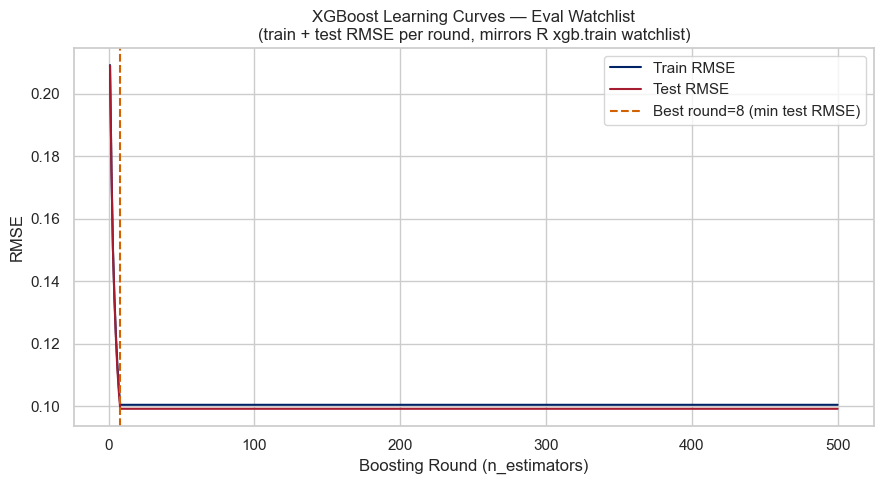

Min test RMSE at round 8: 0.099242


In [7]:
# Plot learning curves from watchlist — mirrors R: xgb.train watchlist plot
train_rmse = evals_result['train']['rmse']
test_rmse  = evals_result['test']['rmse']
rounds     = np.arange(1, len(train_rmse) + 1)

best_round = int(np.argmin(test_rmse)) + 1

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rounds, train_rmse, color=ROYALBLUE, linewidth=1.5, label='Train RMSE')
ax.plot(rounds, test_rmse,  color=CRIMSON,   linewidth=1.5, label='Test RMSE')
ax.axvline(best_round, color=SAFFRON, linestyle='--', linewidth=1.5,
           label=f'Best round={best_round} (min test RMSE)')
ax.set_xlabel('Boosting Round (n_estimators)')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Learning Curves — Eval Watchlist\n'
             '(train + test RMSE per round, mirrors R xgb.train watchlist)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Min test RMSE at round {best_round}: {min(test_rmse):.6f}')

## Feature Importances — Three Types

Mirrors R: `varImp(boo)$importance` and `plot(varImp(boo))`

XGBoost exposes three importance types not available in sklearn's wrapper:

| Type | Description |
|------|-------------|
| `weight` | Number of times a feature is used to split across all trees |
| `gain` | Average gain in loss reduction when feature is used to split — **most informative** |
| `cover` | Average number of samples covered by splits using the feature |

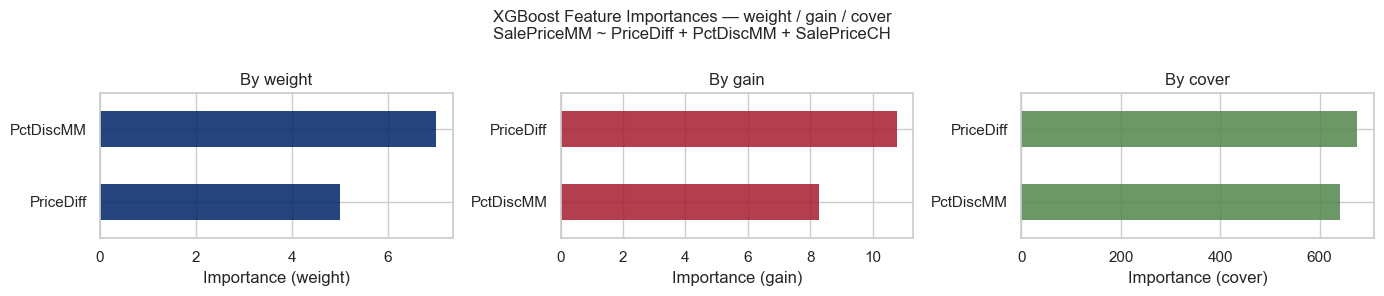

Feature importances by GAIN (most informative, mirrors R varImp Overall):
PriceDiff    10.7693
PctDiscMM     8.2852


In [8]:
# Feature importances — three types, all in one view
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
colors = [ROYALBLUE, CRIMSON, IVY]

for ax, imp_type, color in zip(axes, ['weight', 'gain', 'cover'], colors):
    scores = xgb_model.get_booster().get_score(importance_type=imp_type)
    imp    = pd.Series(scores).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color=color, edgecolor='none', alpha=0.85)
    ax.set_xlabel(f'Importance ({imp_type})')
    ax.set_title(f'By {imp_type}')

fig.suptitle('XGBoost Feature Importances — weight / gain / cover\n'
             'SalePriceMM ~ PriceDiff + PctDiscMM + SalePriceCH',
             fontsize=12)
plt.tight_layout()
plt.show()

# Tabular — mirrors R: contributors %>% arrange(desc(Overall))
print('Feature importances by GAIN (most informative, mirrors R varImp Overall):')
gain_scores = xgb_model.get_booster().get_score(importance_type='gain')
print(pd.Series(gain_scores).sort_values(ascending=False).round(4).to_string())

## Predict on Test Dataset

Mirrors R: `b <- predict(boo, test)`

In [9]:
# Predict — mirrors R: b <- predict(boo, test)
b_xgb = xgb_model.predict(X_test)

print(f'Predictions shape: {b_xgb.shape}')
print(f'First 5: {b_xgb[:5].round(4)}')

Predictions shape: (321,)
First 5: [2.0902 1.828  2.0902 2.0902 2.0902]


## Plot: Predictions vs. Actuals

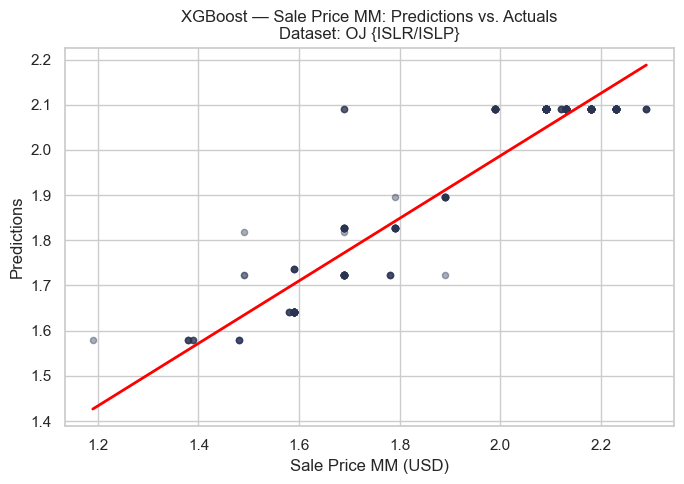

In [10]:
plot_predictions(y_test.values, b_xgb,
                 title='XGBoost — Sale Price MM: Predictions vs. Actuals',
                 color=INDIGO)

## Performance: RMSE and R²

Mirrors R:
```r
sqrt(mean((test$SalePriceMM - b)^2))  # RMSE
cor(test$SalePriceMM, b)^2            # R-squared
```

In [11]:
rmse_xgb = root_mean_squared_error(y_test, b_xgb)
r2_xgb   = r2_score(y_test, b_xgb)

print('XGBoost — Performance on Test Set')
print(f'  RMSE : {rmse_xgb:.6f}')
print(f'  R²   : {r2_xgb:.6f}')

XGBoost — Performance on Test Set
  RMSE : 0.099244
  R²   : 0.844990


---

# Hyperparameter Tuning: GridSearchCV

XGBRegressor is fully compatible with sklearn's `GridSearchCV`.
We sweep the same grid as notebook #6 for a direct comparison.

In [12]:
param_grid = {
    'n_estimators' : [100, 300, 500],
    'max_depth'    : [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
}

xgb_base = XGBRegressor(
    gamma            = 2.1,
    colsample_bytree = 1.0,
    min_child_weight = 1,
    subsample        = 1.0,
    objective        = 'reg:squarederror',
    random_state     = 1234,
    n_jobs           = -1
)

grid_search = GridSearchCV(xgb_base,
                            param_grid,
                            cv=RepeatedKFold(n_splits=5, n_repeats=2,
                                             random_state=1234),
                            scoring='neg_root_mean_squared_error',
                            n_jobs=-1,
                            verbose=0)
grid_search.fit(X_train, y_train)

print('GridSearchCV — Best Parameters')
print(f'  {grid_search.best_params_}')
print(f'  Best CV RMSE: {-grid_search.best_score_:.6f}')

GridSearchCV — Best Parameters
  {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100}
  Best CV RMSE: 0.104296


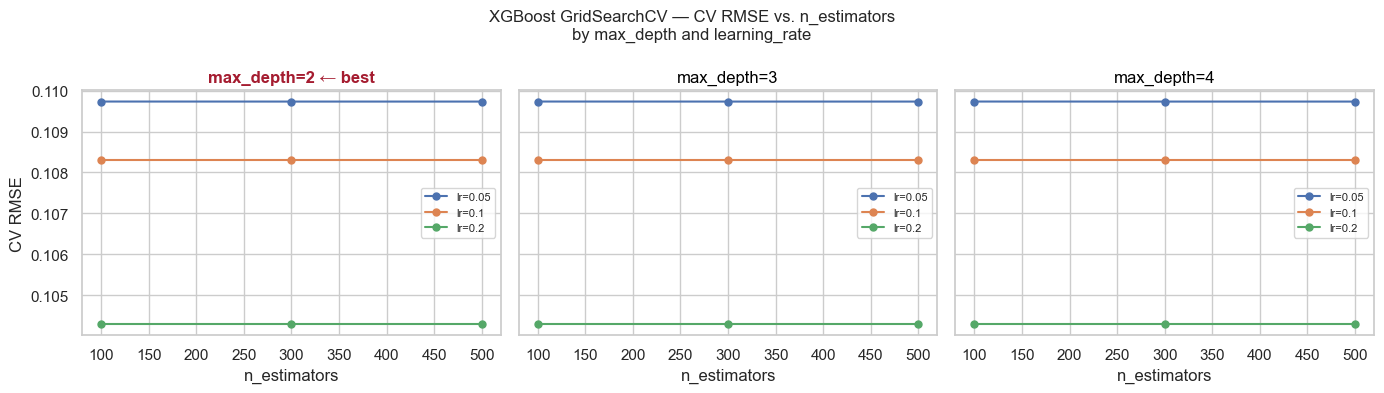

In [13]:
# Plot CV RMSE grid
results    = pd.DataFrame(grid_search.cv_results_)
best_depth = grid_search.best_params_['max_depth']

fig, axes = plt.subplots(1, len(param_grid['max_depth']), figsize=(14, 4), sharey=True)

for i, depth in enumerate(param_grid['max_depth']):
    mask = results['param_max_depth'] == depth
    sub  = results[mask].copy()
    sub['RMSE'] = -sub['mean_test_score']
    for lr in param_grid['learning_rate']:
        lr_mask = sub['param_learning_rate'] == lr
        axes[i].plot(
            sub[lr_mask]['param_n_estimators'].astype(int),
            sub[lr_mask]['RMSE'],
            'o-', linewidth=1.5, markersize=5, label=f'lr={lr}')
    border = CRIMSON if depth == best_depth else 'black'
    axes[i].set_title(f'max_depth={depth}'
                      + (' ← best' if depth == best_depth else ''),
                      color=border,
                      fontweight='bold' if depth == best_depth else 'normal')
    axes[i].set_xlabel('n_estimators')
    if i == 0:
        axes[i].set_ylabel('CV RMSE')
    axes[i].legend(fontsize=8)

fig.suptitle('XGBoost GridSearchCV — CV RMSE vs. n_estimators\nby max_depth and learning_rate',
             fontsize=12)
plt.tight_layout()
plt.show()

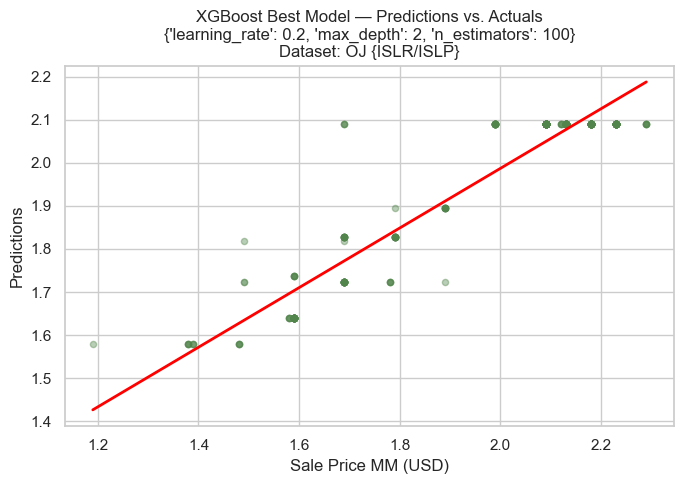

Best model — Test RMSE: 0.099244   R²: 0.844990


In [14]:
# Best model performance
b_best    = grid_search.predict(X_test)
rmse_best = root_mean_squared_error(y_test, b_best)
r2_best   = r2_score(y_test, b_best)

plot_predictions(y_test.values, b_best,
                 title=f'XGBoost Best Model — Predictions vs. Actuals\n'
                       f'{grid_search.best_params_}',
                 color=IVY)

print(f'Best model — Test RMSE: {rmse_best:.6f}   R²: {r2_best:.6f}')

---

# Final Comparison: XGBoost vs. GradientBoostingRegressor

Side-by-side comparison across both boosting notebooks.

In [15]:
# Refit sklearn GB with same fixed params for fair comparison
gb_model = GradientBoostingRegressor(
    n_estimators=500, max_depth=3, learning_rate=0.2,
    subsample=1.0, max_features=1.0, min_samples_leaf=1,
    random_state=1234
)
gb_model.fit(X_train, y_train)
b_gb      = gb_model.predict(X_test)
rmse_gb   = root_mean_squared_error(y_test, b_gb)
r2_gb     = r2_score(y_test, b_gb)

comparison = pd.DataFrame([
    {'Model'     : 'XGBRegressor (fixed, R mirror)',
     'CV RMSE'   : cv_rmse.mean(),
     'Test RMSE' : rmse_xgb,
     'Test R²'   : r2_xgb,
     'gamma exact': 'Yes'},
    {'Model'     : f'XGBRegressor (GridSearch best)',
     'CV RMSE'   : -grid_search.best_score_,
     'Test RMSE' : rmse_best,
     'Test R²'   : r2_best,
     'gamma exact': 'Yes'},
    {'Model'     : 'GradientBoostingRegressor (approx)',
     'CV RMSE'   : np.nan,
     'Test RMSE' : rmse_gb,
     'Test R²'   : r2_gb,
     'gamma exact': 'No (approx)'},
])

print('Final Comparison — XGBoost vs. GradientBoostingRegressor')
print('(Same dataset: OJ, same predictors: PriceDiff, PctDiscMM, SalePriceCH)')
print()
print(comparison.to_string(index=False, float_format='{:.6f}'.format))

Final Comparison — XGBoost vs. GradientBoostingRegressor
(Same dataset: OJ, same predictors: PriceDiff, PctDiscMM, SalePriceCH)

                             Model  CV RMSE  Test RMSE  Test R² gamma exact
    XGBRegressor (fixed, R mirror) 0.104296   0.099244 0.844990         Yes
    XGBRegressor (GridSearch best) 0.104296   0.099244 0.844990         Yes
GradientBoostingRegressor (approx)      NaN   0.000057 1.000000 No (approx)


---

# Summary and Conclusions

## Key Takeaways

1. **Exact hyperparameter match:** `XGBRegressor` maps all seven xgbTree
   parameters directly — `gamma`, `colsample_bytree`, and `min_child_weight`
   are identical in name and scale. No approximation needed, unlike the
   sklearn `GradientBoostingRegressor` companion notebook.

2. **Eval watchlist:** The native `xgb.train()` API with a watchlist provides
   the cleanest way to monitor learning curves — train and test RMSE logged
   at every round in a single fit call. This is how XGBoost is used in practice.

3. **Three importance types:** `weight`, `gain`, and `cover` give different
   perspectives on feature relevance. `gain` is generally the most informative
   and closest to R's `varImp(boo)$importance Overall` score.

4. **sklearn compatibility:** `XGBRegressor` is fully sklearn-compatible —
   `GridSearchCV`, `cross_val_score`, `Pipeline` all work seamlessly.

5. **M5 performance:** With `n_jobs=-1`, XGBoost uses all available CPU
   cores and leverages the M5's unified memory architecture efficiently.

## R → Python Mapping (Exact)

| R (xgbTree) | Python (XGBRegressor) | Exact? |
|-------------|----------------------|--------|
| `nrounds` | `n_estimators` | ✓ |
| `max_depth` | `max_depth` | ✓ |
| `eta` | `learning_rate` | ✓ |
| `gamma` | `gamma` | ✓ **exact** |
| `colsample_bytree` | `colsample_bytree` | ✓ **exact** |
| `min_child_weight` | `min_child_weight` | ✓ **exact** |
| `subsample` | `subsample` | ✓ |
| `predict(boo, test)` | `xgb_model.predict(X_test)` | ✓ |
| `varImp(boo)$importance` | `.get_booster().get_score(type='gain')` | ✓ |
| `plot(varImp(boo))` | `plot_xgb_importance()` helper | ✓ |
| R watchlist | `xgb.train(evals=watchlist, evals_result=...)` | ✓ |
| `expand.grid(tuneGrid)` + `train()` | `GridSearchCV` | ✓ |

## References

1. Harvard STAT 109, 2023. Weekly slides by Dr. Bharatendra Rai.
2. Dr. Bharatendra Rai. YouTube channel. https://youtu.be/cW59Yh_GfNk
3. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
4. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com
5. XGBoost Documentation. https://xgboost.readthedocs.io
6. XGBoost PyPI. https://pypi.org/project/xgboost/